In [90]:
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np

In [91]:
def show(img, color_map: str = 'gray'):
    plt.imshow(img, cmap=color_map)
    plt.show()

In [92]:
#ISIC_0000139

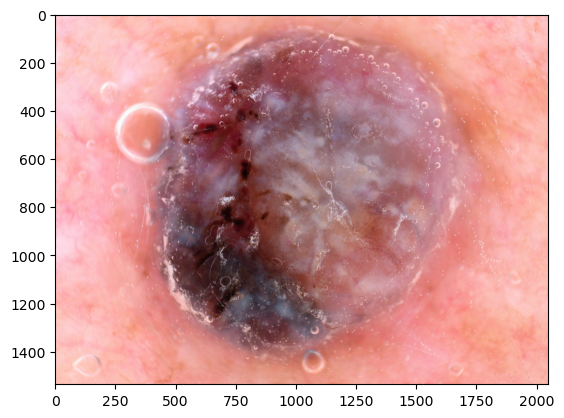

In [ ]:
image = cv.imread('./Skin cancer ISIC The International Skin Imaging Collaboration/Train/melanoma/ISIC_0000147.jpg')

image_hsv = cv.cvtColor(image, cv.COLOR_BGR2HSV)

h,s,v = cv.split(image_hsv)

s_norm = cv.normalize(s, None, 0, 255, cv.NORM_MINMAX)
v_norm = cv.normalize(v, None, 0, 255, cv.NORM_MINMAX)

image_norm = cv.merge([h, s_norm, v_norm])

result = cv.cvtColor(image_norm, cv.COLOR_HSV2RGB)

show(result)


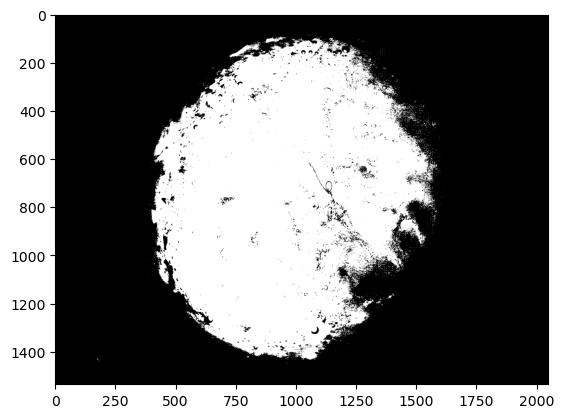

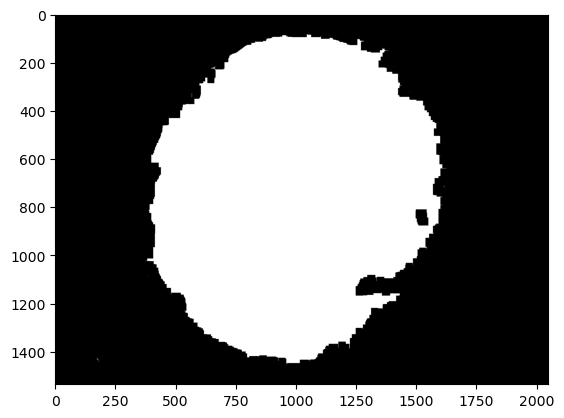

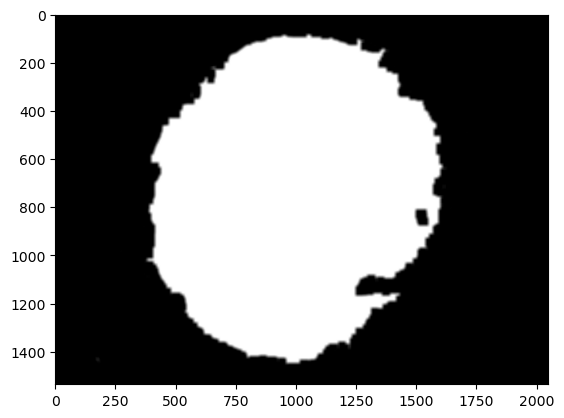

In [94]:
## Threshold

_,binary_image = cv.threshold(v,0, 255, cv.THRESH_BINARY_INV+cv.THRESH_OTSU)
show(binary_image)

## Aplicar closing para eliminar pelos 
kernel = np.ones((15,15), np.uint8)

erode = cv.morphologyEx(binary_image, cv.MORPH_CLOSE, kernel, iterations=2)
show(erode)

blur = cv.blur(erode, (15,15))
show(blur)


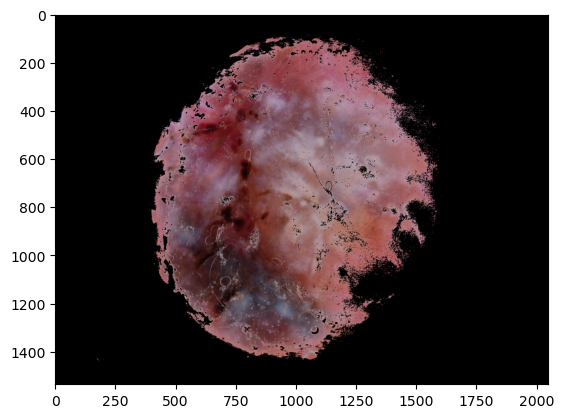

In [95]:
contours, hierarchy = cv.findContours(blur, cv.RETR_TREE, cv.CHAIN_APPROX_SIMPLE)
cv.drawContours(blur, contours, -1, (255, 255,255), 3)

# Hallar el contorno más grande
contour_max = max(contours, key=cv.contourArea)
(h,w) = image.shape[:2]

mask = np.zeros((h,w), np.uint8)


res = cv.bitwise_and(result, result, mask=binary_image)

show(res)